# 📈 Business Report — Thị trường Vàng Đà Nẵng
> Báo cáo tổng hợp dành cho nhà đầu tư / kinh doanh

**Kết hợp**: Phân bổ địa lý + Uy tín + Giá cả → Toàn cảnh thị trường vàng Đà Nẵng

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = ['DejaVu Sans']

shops = pd.read_csv('../data/shops.csv')
reviews = pd.read_csv('../data/reviews.csv')
prices = pd.read_csv('../data/prices.csv')

shops_rated = shops[shops['rating'] > 0].copy()
shops_rated['review_count_filled'] = shops_rated['review_count'].fillna(0)
shops_rated['trust_score'] = (0.6 * shops_rated['rating'] / 5 +
                               0.4 * np.log1p(shops_rated['review_count_filled']) / np.log1p(shops_rated['review_count_filled'].max())) * 100

chains = ['PNJ', 'DOJI', 'SJC', 'BTMC', 'Bao Tin', 'Bảo Tín']
shops_rated['is_chain'] = shops_rated['name'].apply(lambda n: any(c in n for c in chains))
prices['buy_M'] = prices['buy_price'] / 1e6
prices['sell_M'] = prices['sell_price'] / 1e6
prices['spread_M'] = prices['sell_M'] - prices['buy_M']

print('Data loaded OK')
print(f'Shops: {len(shops)}, Reviews: {len(reviews)}, Prices: {len(prices)}')

Data loaded OK
Shops: 150, Reviews: 527, Prices: 42


## 📊 Dashboard Tổng hợp

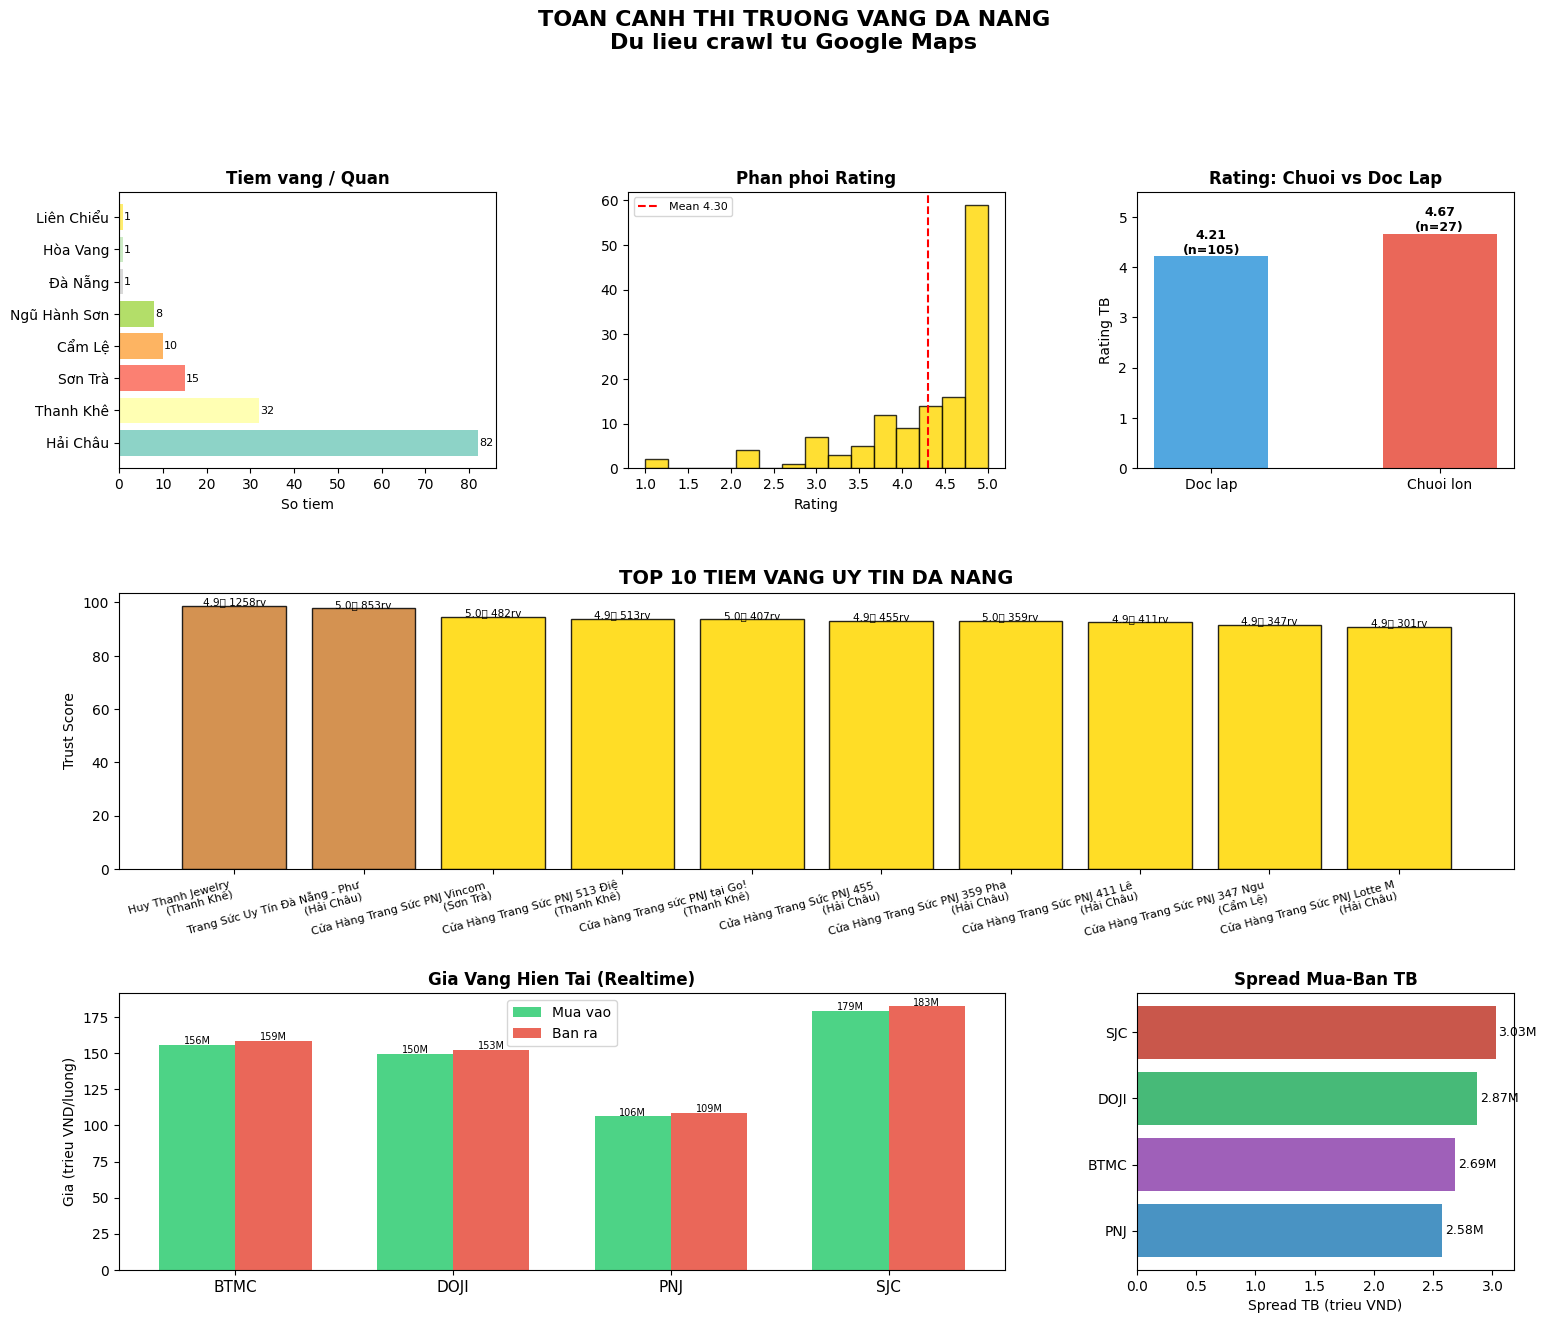

Dashboard saved: data/business_dashboard.png


In [2]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. District distribution
ax1 = fig.add_subplot(gs[0, 0])
district_counts = shops['district'].value_counts()
colors1 = plt.cm.Set3(np.linspace(0, 1, len(district_counts)))
ax1.barh(district_counts.index, district_counts.values, color=colors1)
ax1.set_title('Tiem vang / Quan', fontweight='bold')
ax1.set_xlabel('So tiem')
for i, v in enumerate(district_counts.values):
    ax1.text(v + 0.2, i, str(v), va='center', fontsize=8)

# 2. Rating distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(shops_rated['rating'], bins=15, color='gold', edgecolor='black', alpha=0.8)
ax2.axvline(shops_rated['rating'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean {shops_rated["rating"].mean():.2f}')
ax2.set_title('Phan phoi Rating', fontweight='bold')
ax2.set_xlabel('Rating')
ax2.legend(fontsize=8)

# 3. Chain vs Independent
ax3 = fig.add_subplot(gs[0, 2])
chain_data = shops_rated.groupby('is_chain')['rating'].agg(['mean', 'count'])
labels = ['Doc lap', 'Chuoi lon']
ax3.bar(labels, chain_data['mean'], color=['#3498DB', '#E74C3C'], alpha=0.85, width=0.5)
ax3.set_ylim(0, 5.5)
ax3.set_title('Rating: Chuoi vs Doc Lap', fontweight='bold')
ax3.set_ylabel('Rating TB')
for i, (is_chain, row) in enumerate(chain_data.iterrows()):
    ax3.text(i, row['mean'] + 0.05, f'{row["mean"]:.2f}\n(n={int(row["count"])})',
             ha='center', fontsize=9, fontweight='bold')

# 4. Top 10 trust score
ax4 = fig.add_subplot(gs[1, :])
top10 = shops_rated.nlargest(10, 'trust_score')
colors4 = ['#FFD700' if any(c in n for c in ['PNJ']) else
           '#C0C0C0' if any(c in n for c in ['DOJI', 'SJC', 'BTMC']) else
           '#CD7F32' for n in top10['name']]
bars = ax4.bar(range(len(top10)), top10['trust_score'], color=colors4, edgecolor='black', alpha=0.85)
ax4.set_xticks(range(len(top10)))
ax4.set_xticklabels([f"{r['name'][:30]}\n({r['district']})" for _, r in top10.iterrows()],
                     fontsize=8, rotation=15, ha='right')
ax4.set_ylabel('Trust Score')
ax4.set_title('TOP 10 TIEM VANG UY TIN DA NANG', fontsize=14, fontweight='bold')
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{row["rating"]}⭐ {int(row["review_count_filled"])}rv',
             ha='center', fontsize=7.5)

# 5. Price comparison
ax5 = fig.add_subplot(gs[2, :2])
source_price = prices.groupby('source_name')[['buy_M', 'sell_M']].mean().reset_index()
x5 = range(len(source_price))
w = 0.35
ax5.bar([i - w/2 for i in x5], source_price['buy_M'], w, label='Mua vao', color='#2ECC71', alpha=0.85)
ax5.bar([i + w/2 for i in x5], source_price['sell_M'], w, label='Ban ra', color='#E74C3C', alpha=0.85)
ax5.set_xticks(x5)
ax5.set_xticklabels(source_price['source_name'], fontsize=11)
ax5.set_ylabel('Gia (trieu VND/luong)')
ax5.set_title('Gia Vang Hien Tai (Realtime)', fontweight='bold')
ax5.legend()
for i, row in source_price.iterrows():
    ax5.text(i - w/2, row['buy_M'] + 0.5, f'{row["buy_M"]:.0f}M', ha='center', fontsize=7)
    ax5.text(i + w/2, row['sell_M'] + 0.5, f'{row["sell_M"]:.0f}M', ha='center', fontsize=7)

# 6. Spread
ax6 = fig.add_subplot(gs[2, 2])
spread_data = prices.groupby('source_name')['spread_M'].mean().sort_values()
src_colors = {'SJC': '#C0392B', 'PNJ': '#2980B9', 'DOJI': '#27AE60', 'BTMC': '#8E44AD'}
ax6.barh(spread_data.index, spread_data.values,
          color=[src_colors.get(s, 'gray') for s in spread_data.index], alpha=0.85)
ax6.set_xlabel('Spread TB (trieu VND)')
ax6.set_title('Spread Mua-Ban TB', fontweight='bold')
for i, (src, v) in enumerate(spread_data.items()):
    ax6.text(v + 0.02, i, f'{v:.2f}M', va='center', fontsize=9)

plt.suptitle('TOAN CANH THI TRUONG VANG DA NANG\nDu lieu crawl tu Google Maps', 
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('../data/business_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: data/business_dashboard.png')

## 📋 Executive Summary

In [3]:
print('=' * 60)
print('EXECUTIVE SUMMARY — THI TRUONG VANG DA NANG')
print('=' * 60)

print(f"""
1. QUY MO THI TRUONG
   - {len(shops)} tiem vang duoc map tai Da Nang
   - {len(shops[shops['is_chain'] if 'is_chain' in shops.columns else shops.index.isin([])]):} tiem chuoi lon (PNJ/DOJI/SJC)
   - Tap trung chu yeu: {shops['district'].value_counts().index[0]} ({shops['district'].value_counts().iloc[0]} tiem)

2. CHAT LUONG DICH VU  
   - Rating trung binh toan thi truong: {shops_rated['rating'].mean():.2f}/5.0
   - Tiem rating >= 4.5: {len(shops_rated[shops_rated['rating']>=4.5])} ({len(shops_rated[shops_rated['rating']>=4.5])/len(shops_rated)*100:.0f}%)
   - Tiem rating < 3.5: {len(shops_rated[shops_rated['rating']<3.5])} ({len(shops_rated[shops_rated['rating']<3.5])/len(shops_rated)*100:.0f}%)
   - Tong reviews: {len(reviews)} tu Google Maps

3. GIA CA HIEN TAI
   - SJC vang mien 1L-10L: {prices[(prices.source_name=='SJC') & (prices.gold_type.str.contains('1L', na=False))]['sell_M'].mean():.1f}M VND/luong (ban)
   - PNJ vang 9999 nhan:   {prices[(prices.source_name=='PNJ') & (prices.gold_type.str.contains('9999', na=False) | prices.gold_type.str.contains('24K', na=False))]['sell_M'].mean():.1f}M VND/luong
   - DOJI vang mien:       {prices[(prices.source_name=='DOJI') & (prices.gold_type.str.contains('mien', na=False))]['sell_M'].mean():.1f}M VND/luong
   - Spread TB: {prices['spread_M'].mean():.2f}M VND/luong ({prices['spread_pct'].mean():.1f}%)

4. TOP TIEM UY TIN (Trust Score)
""")
top5 = shops_rated.nlargest(5, 'trust_score')
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f'   #{i} {row["name"][:40]:40} | {row["district"]:15} | {row["rating"]}⭐ | {int(row["review_count_filled"])} reviews')

print(f"""
5. CO HOI & THACH THUC
   [+] Quan {shops['district'].value_counts().tail(1).index[0]} con it tiem ({shops['district'].value_counts().iloc[-1]} tiem) — thi phan mo
   [+] 30% tiem rating < 4.0 — co the canh tranh ve dich vu
   [-] PNJ/DOJI chiem uu the ve uy tin va he thong
   [-] Spread ~{prices['spread_M'].mean():.1f}M VND/luong — kho canh tranh gia

Nguon du lieu: Google Maps (crawl {pd.Timestamp.now().strftime('%Y-%m-%d')})
Gia vang: api2.giavang.net (realtime)
""")

EXECUTIVE SUMMARY — THI TRUONG VANG DA NANG

1. QUY MO THI TRUONG
   - 150 tiem vang duoc map tai Da Nang
   - 0 tiem chuoi lon (PNJ/DOJI/SJC)
   - Tap trung chu yeu: Hải Châu (82 tiem)

2. CHAT LUONG DICH VU  
   - Rating trung binh toan thi truong: 4.30/5.0
   - Tiem rating >= 4.5: 75 (57%)
   - Tiem rating < 3.5: 19 (14%)
   - Tong reviews: 527 tu Google Maps

3. GIA CA HIEN TAI
   - SJC vang mien 1L-10L: 182.6M VND/luong (ban)
   - PNJ vang 9999 nhan:   119.0M VND/luong
   - DOJI vang mien:       nanM VND/luong
   - Spread TB: 2.78M VND/luong (2.1%)

4. TOP TIEM UY TIN (Trust Score)

   #1 Huy Thanh Jewelry                        | Thanh Khê       | 4.9⭐ | 1258 reviews
   #2 Trang Sức Uy Tín Đà Nẵng - Phước swiss   | Hải Châu        | 5.0⭐ | 853 reviews
   #3 Cửa Hàng Trang Sức PNJ Vincom Đà Nẵng    | Sơn Trà         | 5.0⭐ | 482 reviews
   #4 Cửa Hàng Trang Sức PNJ 513 Điện Biên Phủ | Thanh Khê       | 4.9⭐ | 513 reviews
   #5 Cửa hàng Trang sức PNJ tại Go! Đà Nẵng   | Thanh Khê  